# Task 3: Language Processing

**Project:** Financial Phrase Sentiment Classification  
**Goal:** Classify short financial phrases into **negative**, **neutral** and **positive** sentiment classes.  

This notebook follows the language processing task pipeline required for the portfolio. It starts with dataset loading and cleaning, then performs tokenization and sequence padding, builds three recurrent neural network models, compares their performance, analyzes errors and finally creates a simple Gradio prediction interface. The three models are:

- Simple RNN with a trainable embedding layer
- Bidirectional LSTM with a trainable embedding layer
- Bidirectional LSTM with pretrained GloVe embeddings loaded through Gensim

The dataset used here is a financial phrase dataset, so the cleaning, examples and prediction interface are all written for financial and business text rather than casual social media sentiment.

## Step 1: Install and Import Required Libraries

This section installs and imports all packages required for the NLP pipeline. The notebook uses:

- **Pandas and NumPy** for data loading, manipulation and numerical operations
- **Matplotlib and WordCloud** for visualizing word frequency and cleaned text
- **NLTK and contractions** for text preprocessing, including stopword removal, contraction expansion and lemmatization
- **Scikit-learn** for train-test splitting, label encoding, class weights and evaluation metrics
- **TensorFlow and Keras** for building, training and evaluating RNN and LSTM models
- **Gensim** for loading pretrained GloVe word embeddings
- **Gradio** for the final real-time prediction interface

In [ ]:
!pip -q install contractions wordcloud gradio gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.3 MB/s eta 0:00:00


In [ ]:
import os
import re
import time
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


TensorFlow version: 2.20.0
GPU available: True


In [ ]:
PROJECT_NAME = 'Financial Phrase Sentiment Classification'

DATA_PATH = '/content/drive/MyDrive/college/sem6/AI&ML/Assessment/NLP/financial_phrase.csv'

TEXT_COLUMN = 'text'
LABEL_COLUMN = 'label'
EXPECTED_LABELS = ['negative', 'neutral', 'positive']

# Model/training hyperparameters
VOCAB_SIZE = 12000
EMBEDDING_DIM = 100
BATCH_SIZE = 64
EPOCHS = 15
VALIDATION_SPLIT_FROM_TRAIN = 0.1
PADDING_PERCENTILE = 95

PRETRAINED_EMBEDDING_NAME = 'glove-wiki-gigaword-100'

FINANCIAL_TEST_SENTENCES = [
    'The company reported higher revenue and stronger operating profit.',
    'Sales declined sharply and the company reported a loss.',
    'The company announced a new board meeting for next week.',
    'Net sales increased by 20 percent compared with last year.',
    'Operating profit fell because demand remained weak.'
]

## Step 3: Load the Financial Phrase Dataset

This section mounts Google Drive and loads the CSV file containing the financial phrase dataset. The dataset is expected to have two required columns:

- `text`: the financial phrase or business sentence
- `label`: the sentiment category for the phrase

The notebook checks whether the dataset path exists before loading it. This prevents silent errors where the notebook continues without actually reading the assigned dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Upload the CSV or update DATA_PATH in the configuration cell."
    )

df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
display(df.head())
print('Columns:', df.columns.tolist())

Dataset shape: (2264, 2)


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


Columns: ['text', 'label']


## Step 4: Dataset Understanding and Basic Checks

Before training any model, the dataset is checked for structure and quality. This step confirms that the required columns are present, standardizes the column names, checks whether labels match the expected three classes and removes missing or duplicate records.

This section also displays the class distribution. This is important because the financial phrase dataset is imbalanced, with many more neutral samples than negative samples. Identifying this imbalance early helps justify the later use of class weights during model training.

Total records before cleaning: 2264
Missing values:
text     0
label    0
dtype: int64
Total records after dropping missing/duplicates: 2259
Class distribution:
label
negative     303
neutral     1386
positive     570
Name: count, dtype: int64


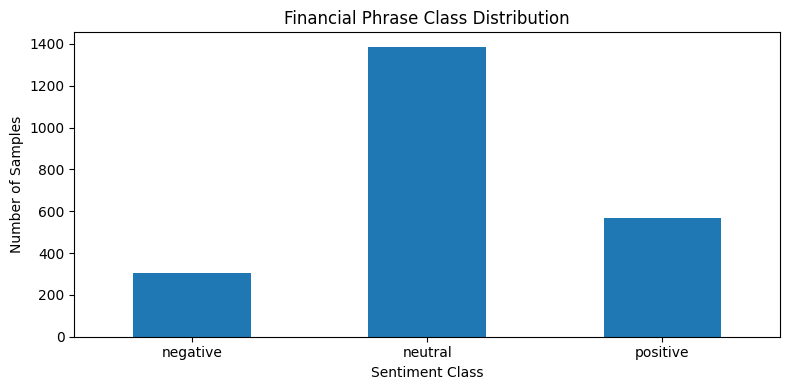

In [ ]:
required_cols = [TEXT_COLUMN, LABEL_COLUMN]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}. Available columns: {df.columns.tolist()}')

# Keep only required columns for financial phrase sentiment classification.
data = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()
data.columns = ['text', 'label']
data['text'] = data['text'].astype(str)
data['label'] = data['label'].astype(str).str.strip().str.lower()

unexpected_labels = sorted(set(data['label'].dropna()) - set(EXPECTED_LABELS))
if unexpected_labels:
    raise ValueError(f'Unexpected labels found: {unexpected_labels}. Expected labels are: {EXPECTED_LABELS}')

print('Total records before cleaning:', len(data))
print('Missing values:')
print(data.isna().sum())

# Drop missing and duplicate rows.
data = data.dropna(subset=['text', 'label'])
data = data.drop_duplicates(subset=['text', 'label']).reset_index(drop=True)

print('Total records after dropping missing/duplicates:', len(data))
print('Class distribution:')
print(data['label'].value_counts().reindex(EXPECTED_LABELS))

plt.figure(figsize=(8, 4))
data['label'].value_counts().reindex(EXPECTED_LABELS).plot(kind='bar')
plt.title('Financial Phrase Class Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 5: Text Cleaning and Preprocessing

This section cleans the raw financial text before tokenization. The cleaning function performs the following operations:

- Converts all text to lowercase
- Expands contractions so that shortened words are made explicit
- Removes URLs, mentions, hashtag symbols, numbers and special characters
- Removes common English stopwords
- Preserves financially meaningful signal words such as `profit`, `loss`, `increase`, `decrease`, `rose`, `fell`, `higher`, `lower`, `weak` and `strong`
- Lemmatizes words so that different forms of a word are reduced to a common base form

The preservation of financial signal words is important because ordinary stopword removal can sometimes remove words that carry meaning in financial comparison statements.

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Keep words that carry sentiment or direction in financial-news sentences.
financial_signal_words = {
    'no', 'not', 'nor', 'never',
    'up', 'down', 'above', 'below', 'over', 'under',
    'more', 'most', 'less', 'least',
    'against', 'between', 'from', 'to',
    'profit', 'loss', 'sales', 'revenue', 'growth', 'decline', 'increase', 'decrease',
    'rose', 'fell', 'rise', 'fall', 'higher', 'lower', 'weak', 'strong'
}
stop_words = stop_words - financial_signal_words

def clean_text(text):
    """Clean financial phrase text while preserving important business sentiment words."""
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)     # remove URLs
    text = re.sub(r'@\w+', ' ', text)                  # remove mentions if present
    text = re.sub(r'#', '', text)                       # remove hashtag symbol if present
    text = re.sub(r'\d+', ' ', text)                    # remove numbers as required by the guideline
    text = re.sub(r'[^a-z\s]', ' ', text)               # remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = []
    for word in text.split():
        if word not in stop_words and len(word) > 1:
            tokens.append(lemmatizer.lemmatize(word))
    return ' '.join(tokens)

data['clean_text'] = data['text'].apply(clean_text)

# Remove rows that become empty after cleaning.
data = data[data['clean_text'].str.strip().astype(bool)].reset_index(drop=True)

print('Records after text cleaning:', len(data))
display(data[['text', 'clean_text', 'label']].head(10))

Records after text cleaning: 2259


,text,clean_text,label
0,"According to Gran , the company has no plans t...",according to gran company no plan to move prod...,neutral
1,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sale doubled to eu...,positive
2,"In the third quarter of 2010 , net sales incre...",third quarter net sale increased to eur mn ope...,positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose to eur mn from eur mn co...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",operating profit totalled eur mn up from eur m...,positive
5,Finnish Talentum reports its operating profit ...,finnish talentum report operating profit incre...,positive
6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,clothing retail chain sepp sale increased to e...,positive
7,Consolidated net sales increased 16 % to reach...,consolidated net sale increased to reach eur o...,positive
8,Foundries division reports its sales increased...,foundry division report sale increased to eur ...,positive
9,"HELSINKI ( AFX ) - Shares closed higher , led ...",helsinki afx share closed higher led nokia ann...,positive


## Step 6: Visualize the Cleaned Text

After cleaning the text, this section explores the vocabulary of the dataset. The top 20 most frequent words are displayed using a bar chart, and a word cloud is generated to show which words dominate the cleaned financial phrases.

This helps confirm that the preprocessing has worked correctly and that the text belongs to the financial domain. Common terms such as company, profit, sale, revenue, market and EUR are expected in this dataset.

Vocabulary size after cleaning: 4755
Top 20 frequent words:
[('to', 1086), ('eur', 1017), ('from', 517), ('mn', 500), ('company', 381), ('profit', 325), ('net', 292), ('sale', 279), ('year', 274), ('million', 267), ('share', 265), ('finnish', 224), ('said', 206), ('operating', 202), ('mln', 199), ('period', 194), ('quarter', 188), ('group', 161), ('euro', 155), ('service', 138)]


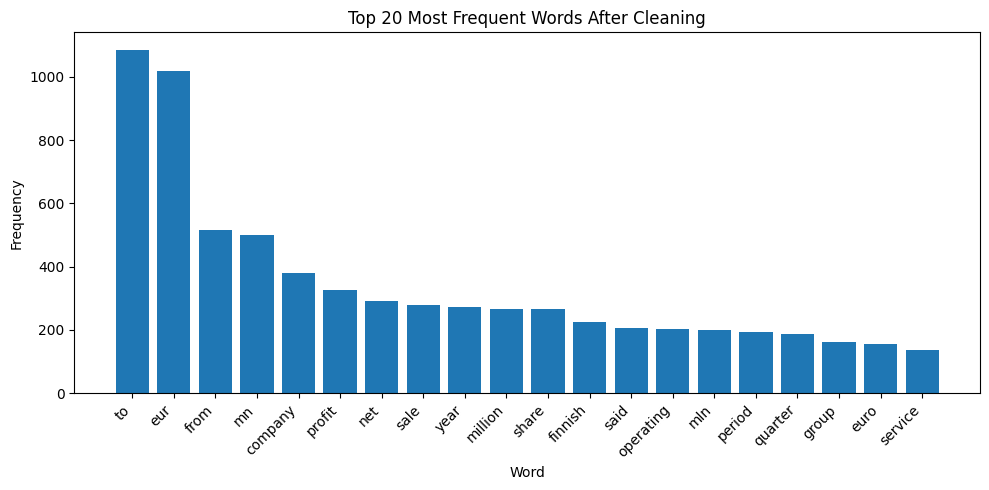

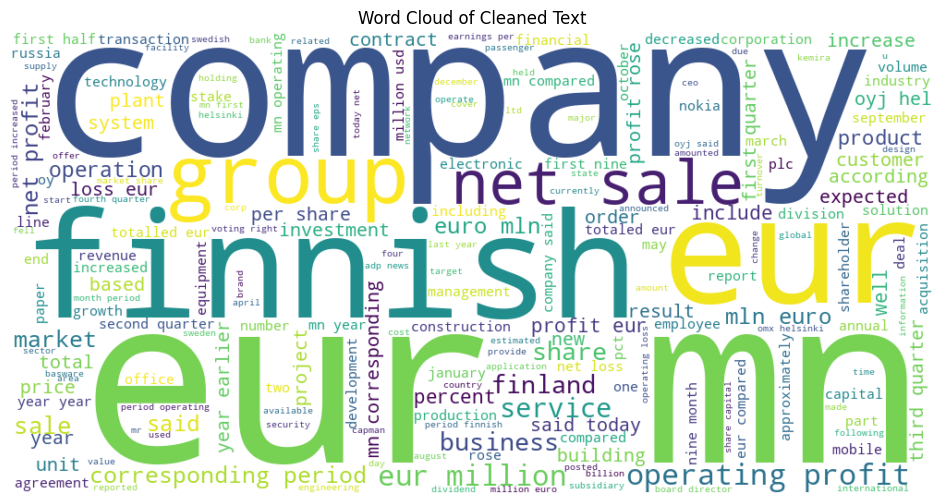

In [ ]:
all_words = ' '.join(data['clean_text']).split()
word_freq = Counter(all_words)

print('Vocabulary size after cleaning:', len(word_freq))
print('Top 20 frequent words:')
print(word_freq.most_common(20))

freq_df = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])
plt.figure(figsize=(10, 5))
plt.bar(freq_df['word'], freq_df['count'])
plt.title('Top 20 Most Frequent Words After Cleaning')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(' '.join(all_words))
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Text')
plt.show()

## Step 7: Encode Labels and Create Train, Validation and Test Sets

The sentiment labels are converted into numerical form using `LabelEncoder`, which allows the neural network to train on class indices. The dataset is then split into training and testing sets using an 80/20 stratified split.

A separate validation set is then created from the training data. This validation set is used during training to monitor generalization and trigger callbacks such as early stopping. Stratification is used so that the class proportions remain similar across the training, validation and testing sets.

In [ ]:
label_encoder = LabelEncoder()
data['label_encoded'] = label_encoder.fit_transform(data['label'])
class_names = label_encoder.classes_
num_classes = len(class_names)

print('Classes in model order:', list(class_names))
print('Number of classes:', num_classes)

# 80/20 train-test split
X_train_full_text, X_test_text, y_train_full, y_test = train_test_split(
    data['clean_text'],
    data['label_encoded'],
    test_size=0.20,
    random_state=SEED,
    stratify=data['label_encoded']
)

# Separate a stratified validation set from training data for stable validation curves.
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_train_full_text,
    y_train_full,
    test_size=VALIDATION_SPLIT_FROM_TRAIN,
    random_state=SEED,
    stratify=y_train_full
)

print('Training samples:', len(X_train_text))
print('Validation samples:', len(X_val_text))
print('Testing samples:', len(X_test_text))
print('\nTraining class distribution:')
print(pd.Series(label_encoder.inverse_transform(y_train)).value_counts().reindex(class_names))
print('\nValidation class distribution:')
print(pd.Series(label_encoder.inverse_transform(y_val)).value_counts().reindex(class_names))
print('\nTesting class distribution:')
print(pd.Series(label_encoder.inverse_transform(y_test)).value_counts().reindex(class_names))


y_train_model = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_val_model = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)
y_test_model = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)


Classes in model order: ['negative', 'neutral', 'positive']
Number of classes: 3
Training samples: 1626
Validation samples: 181
Testing samples: 452

Training class distribution:
negative    218
neutral     998
positive    410
Name: count, dtype: int64

Validation class distribution:
negative     24
neutral     111
positive     46
Name: count, dtype: int64

Testing class distribution:
negative     61
neutral     277
positive    114
Name: count, dtype: int64


## Step 8: Tokenization and Percentile-Based Padding

Neural networks cannot directly process raw text, so the cleaned sentences are converted into sequences of integer word IDs using the Keras Tokenizer. The tokenizer is fitted only on the training text to avoid leaking information from the validation or test sets.

The sequences are then padded to a fixed length. Instead of using the longest sentence, this notebook uses the 95th percentile sequence length. This avoids making every input unnecessarily long because of a few unusually long phrases. Padding is applied after the sentence, and longer sequences are truncated after the selected maximum length.

In [ ]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

train_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(train_lengths, PADDING_PERCENTILE))
MAX_LEN = max(MAX_LEN, 5)

print(f'{PADDING_PERCENTILE}th percentile sequence length:', MAX_LEN)
print('Maximum sequence length in training set:', max(train_lengths))

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

word_index = tokenizer.word_index
actual_vocab_size = min(VOCAB_SIZE, len(word_index) + 1)

print('Actual vocabulary size used:', actual_vocab_size)
print('Padded train shape:', X_train_pad.shape)
print('Padded validation shape:', X_val_pad.shape)
print('Padded test shape:', X_test_pad.shape)

95th percentile sequence length: 24
Maximum sequence length in training set: 36
Actual vocabulary size used: 3987
Padded train shape: (1626, 24)
Padded validation shape: (181, 24)
Padded test shape: (452, 24)


## Step 9: Compute Class Weights

The dataset is imbalanced, so class weights are calculated using the training labels. The purpose of class weighting is to make mistakes on minority classes more costly during training.

This is especially important for this dataset because the neutral class has the highest number of samples, while the negative class has far fewer examples. Without class weights, a model could obtain a reasonable accuracy by over-predicting the majority class.

In [ ]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
class_weight_dict

{0: 2.4862385321100917, 1: 0.5430861723446894, 2: 1.3219512195121952}

## Step 10: Helper Functions for Training and Evaluation

This section defines reusable functions for the modelling pipeline. The helper functions are used to:

- Select the correct output layer and loss function for binary or multiclass classification
- Build callbacks such as EarlyStopping, ReduceLROnPlateau, ModelCheckpoint and CSVLogger
- Plot training and validation curves
- Train each model using the same process
- Evaluate each model using accuracy, weighted precision, weighted recall, weighted F1-score, confusion matrix and classification report

Using helper functions keeps the notebook cleaner and makes the comparison between the three models fairer because the same training and evaluation logic is applied to each model.

In [ ]:
def get_output_layer():
    if num_classes == 2:
        return Dense(1, activation='sigmoid')
    return Dense(num_classes, activation='softmax')


def get_loss_function():
    if num_classes == 2:
        return 'binary_crossentropy'
    return 'categorical_crossentropy'


def get_metric_list():
    return ['accuracy']


def build_callbacks(model_name):
    os.makedirs('model_checkpoints', exist_ok=True)
    return [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
        ModelCheckpoint(
            filepath=f'model_checkpoints/{model_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        ),
        CSVLogger(f'{model_name}_training_log.csv')
    ]


def plot_history(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 4))
    plt.plot(hist['loss'], label='Training Loss')
    plt.plot(hist['val_loss'], label='Validation Loss')
    plt.title(f'{title}: Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(hist['accuracy'], label='Training Accuracy')
    plt.plot(hist['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title}: Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()


def convert_predictions(pred_probs):
    if num_classes == 2:
        return (pred_probs.ravel() >= 0.5).astype(int)
    return np.argmax(pred_probs, axis=1)


def evaluate_model(model, model_name):
    pred_probs = model.predict(X_test_pad, verbose=0)
    y_pred = convert_predictions(pred_probs)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )

    print(f'{model_name} Results')
    print('-' * 60)
    print('Accuracy:', round(accuracy, 4))
    print('Weighted Precision:', round(precision, 4))
    print('Weighted Recall:', round(recall, 4))
    print('Weighted F1-score:', round(f1, 4))
    print('Classification Report:')
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, xticks_rotation=45, cmap=None)
    plt.title(f'{model_name}: Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision_weighted': precision,
        'recall_weighted': recall,
        'f1_weighted': f1,
        'predictions': y_pred
    }


def train_model(model, model_name):
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=get_loss_function(),
        metrics=get_metric_list()
    )
    print(model.summary())

    start_time = time.time()
    history = model.fit(
        X_train_pad,
        y_train_model,
        validation_data=(X_val_pad, y_val_model),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=build_callbacks(model_name),
        class_weight=class_weight_dict,
        verbose=1
    )
    training_time = time.time() - start_time
    print(f'Training time for {model_name}: {training_time:.2f} seconds')

    plot_history(history, model_name)
    results = evaluate_model(model, model_name)
    results['training_time_seconds'] = training_time
    return model, history, results

## Step 11: Model A, Simple RNN with Trainable Embeddings

The first model is the baseline recurrent model. It uses a trainable embedding layer followed by a SimpleRNN layer. The embedding layer learns word representations directly from the financial phrase dataset.

This model is useful as a baseline because it is simpler and faster than LSTM models. However, Simple RNNs can struggle with vanishing gradients and may not retain useful information across longer word sequences. For this reason, its performance is expected to be lower than the LSTM models.

Model: "Simple_RNN_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 181ms/step - accuracy: 0.3653 - loss: 1.1270 - val_accuracy: 0.6243 - val_loss: 1.0346 - learning_rate: 0.0010
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3961 - loss: 1.1055 - val_accuracy: 0.6851 - val_loss: 0.9063 - learning_rate: 0.0010
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4932 - loss: 1.0689 - val_accuracy: 0.6961 - val_loss: 0.7952 - learning_rate: 0.0010
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5910 - loss: 1.0165 - val_accuracy: 0.6851 - val_loss: 0.8114 - learning_rate: 0.0010
Epoch 5/15
24/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6444 - loss: 0.9373
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6316 - loss: 0.9681 - val_accuracy: 0.6575 - val_loss: 0.8225 - learning_rate: 0.0010
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6710 - loss: 0.9229 - val_acc

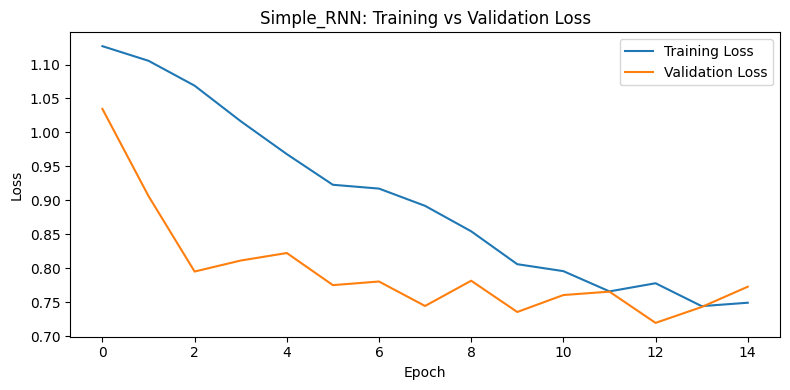

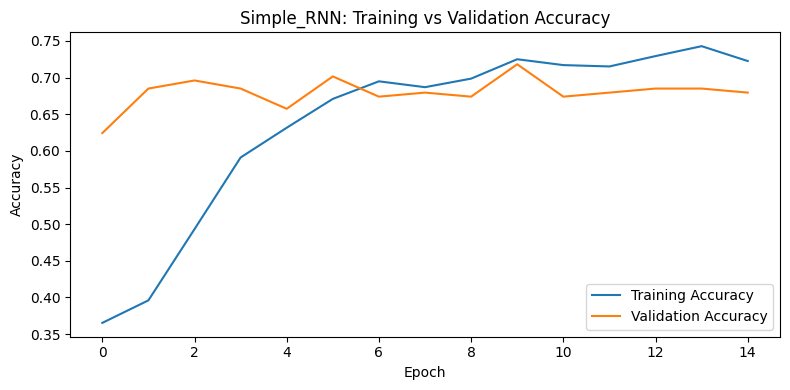

Simple_RNN Results
------------------------------------------------------------
Accuracy: 0.6593
Weighted Precision: 0.7597
Weighted Recall: 0.6593
Weighted F1-score: 0.6353
Classification Report:
              precision    recall  f1-score   support

    negative       0.30      0.85      0.45        61
     neutral       0.89      0.85      0.87       277
    positive       0.69      0.10      0.17       114

    accuracy                           0.66       452
   macro avg       0.63      0.60      0.49       452
weighted avg       0.76      0.66      0.64       452



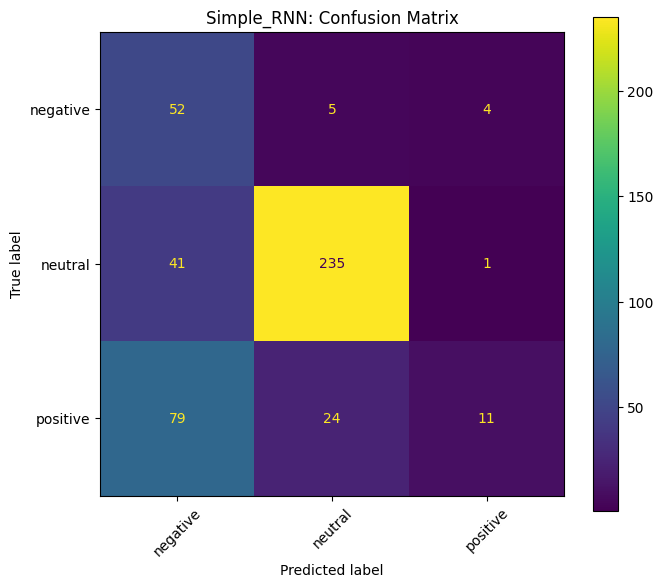

In [ ]:
def build_simple_rnn_model():
    model = Sequential(name='Simple_RNN_Trainable_Embedding')
    model.add(Embedding(input_dim=actual_vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
    model.add(SpatialDropout1D(0.2))
    model.add(SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.4))
    model.add(get_output_layer())
    return model

simple_rnn_model = build_simple_rnn_model()
simple_rnn_model, simple_rnn_history, simple_rnn_results = train_model(simple_rnn_model, 'Simple_RNN')

## Step 12: Model B, Bidirectional LSTM with Trainable Embeddings

The second model uses a bidirectional LSTM. LSTM layers are designed to handle sequence information more effectively than Simple RNNs because their gates control what information is kept, forgotten and passed forward.

The bidirectional wrapper allows the model to read each financial phrase in both directions. This helps the model understand words based on both earlier and later context. The embedding layer is trainable, so the model learns word meanings directly from the dataset rather than relying on external word vectors.

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 388ms/step - accuracy: 0.4914 - loss: 1.1001 - val_accuracy: 0.6851 - val_loss: 1.0471 - learning_rate: 0.0010
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 248ms/step - accuracy: 0.6556 - loss: 0.9848 - val_accuracy: 0.7127 - val_loss: 0.7930 - learning_rate: 0.0010
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.7405 - loss: 0.7807 - val_accuracy: 0.7514 - val_loss: 0.6286 - learning_rate: 0.0010
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.8616 - loss: 0.5369 - val_accuracy: 0.8066 - val_loss: 0.5449 - learning_rate: 0.0010
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.9256 - loss: 0.3147 - val_accuracy: 0.8508 - val_loss: 0.4820 - learning_rate: 0.0010
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.9686 - loss: 0.1639 - val_accuracy: 0.8564 - val_loss: 0.6032 - learning_rate: 0.0010
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9727 - loss: 0.

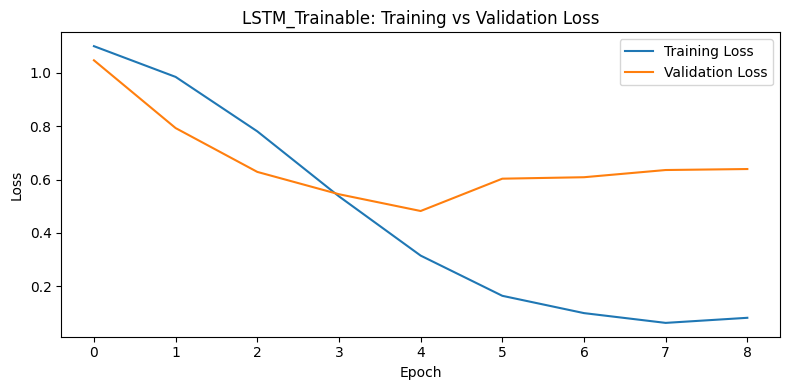

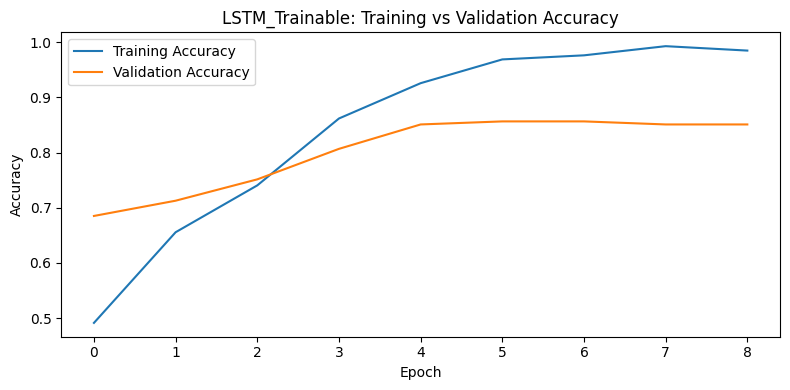

LSTM_Trainable Results
------------------------------------------------------------
Accuracy: 0.8518
Weighted Precision: 0.8514
Weighted Recall: 0.8518
Weighted F1-score: 0.8516
Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.72      0.73        61
     neutral       0.92      0.92      0.92       277
    positive       0.75      0.75      0.75       114

    accuracy                           0.85       452
   macro avg       0.80      0.80      0.80       452
weighted avg       0.85      0.85      0.85       452



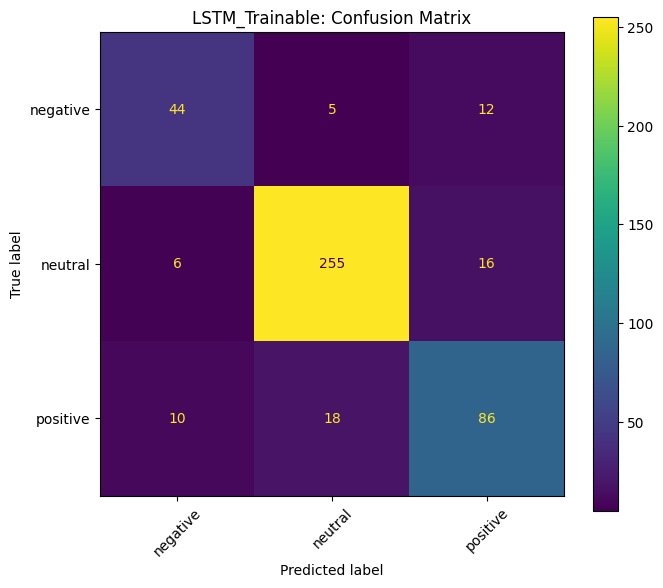

In [ ]:
def build_lstm_model():
    model = Sequential(name='LSTM_Trainable_Embedding')
    model.add(Embedding(input_dim=actual_vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
    model.add(SpatialDropout1D(0.25))
    model.add(Bidirectional(LSTM(64, dropout=0.25, recurrent_dropout=0.15)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.45))
    model.add(get_output_layer())
    return model

lstm_model = build_lstm_model()
lstm_model, lstm_history, lstm_results = train_model(lstm_model, 'LSTM_Trainable')

## Step 13: Load Pretrained GloVe Embeddings

The third model uses pretrained GloVe word vectors loaded through Gensim. The selected embedding is `glove-wiki-gigaword-100`, which provides 100-dimensional word vectors trained on formal text. This is more suitable for financial phrases than a Twitter-based embedding because the dataset contains business and news-style language.

An embedding matrix is created by matching the tokenizer vocabulary to the pretrained GloVe vocabulary. Words found in GloVe receive their pretrained vector. Words not found remain as zero vectors. The coverage value shows how much of the dataset vocabulary is represented in the pretrained embedding model.

In [ ]:
import gensim.downloader as api

print('Pretrained embedding selected for financial phrases:', PRETRAINED_EMBEDDING_NAME)
embedding_model = api.load(PRETRAINED_EMBEDDING_NAME)

# Infer embedding dimension from loaded model.
pretrained_embedding_dim = embedding_model.vector_size
print('Pretrained embedding dimension:', pretrained_embedding_dim)

embedding_matrix = np.zeros((actual_vocab_size, pretrained_embedding_dim))
hits = 0
misses = 0

for word, idx in word_index.items():
    if idx >= actual_vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        hits += 1
    else:
        misses += 1

coverage = hits / max(hits + misses, 1)
print(f'Words found in pretrained GloVe embeddings: {hits}')
print(f'Words not found in pretrained GloVe embeddings: {misses}')
print(f'Coverage: {coverage:.2%}')

Pretrained embedding selected for financial phrases: glove-wiki-gigaword-100
[==================================================] 100.0% 128.1/128.1MB downloaded
Pretrained embedding dimension: 100
Words found in pretrained GloVe embeddings: 3612
Words not found in pretrained GloVe embeddings: 374
Coverage: 90.62%


## Step 14: Model C, Bidirectional LSTM with Pretrained GloVe Embeddings

This model uses the pretrained embedding matrix created in the previous step. The embedding layer is set to non-trainable, meaning the GloVe vectors are preserved during model training. The rest of the model uses a bidirectional LSTM, a dense layer, dropout and a softmax output layer.

This experiment tests whether external pretrained word representations improve performance compared with embeddings learned directly from the financial phrase dataset.

Model: "LSTM_Pretrained_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       398,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 398,700 (1.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 398,700 (1.52 MB)

None
Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 217ms/step - accuracy: 0.4557 - loss: 1.0673 - val_accuracy: 0.6188 - val_loss: 0.9256 - learning_rate: 0.0010
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.6279 - loss: 0.9321 - val_accuracy: 0.6243 - val_loss: 0.8374 - learning_rate: 0.0010
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.6691 - loss: 0.8474 - val_accuracy: 0.6630 - val_loss: 0.7634 - learning_rate: 0.0010
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - accuracy: 0.6913 - loss: 0.8133 - val_accuracy: 0.6740 - val_loss: 0.7279 - learning_rate: 0.0010
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.7060 - loss: 0.7866 - val_accuracy: 0.7182 - val_loss: 0.6337 - learning_rate: 0.0010
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.7288 - loss: 0.7350 - val_accuracy: 0.7238 - val_loss: 0.6137 - learning_rate: 0.0010
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.7312 - loss: 0.7

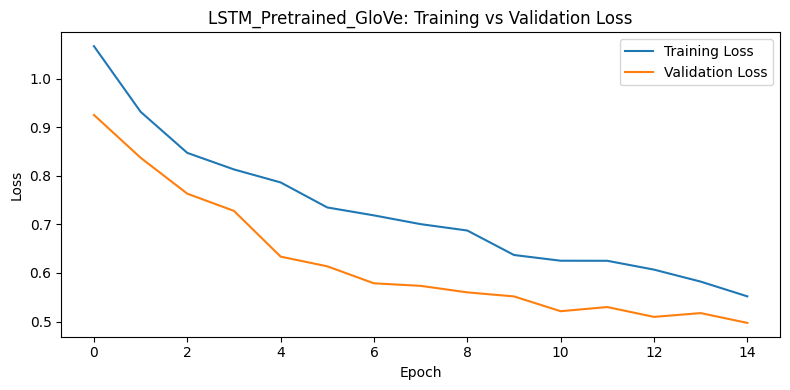

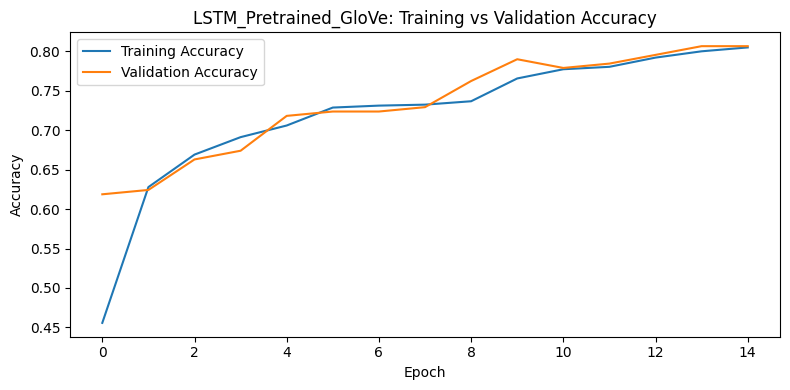

LSTM_Pretrained_GloVe Results
------------------------------------------------------------
Accuracy: 0.8319
Weighted Precision: 0.8435
Weighted Recall: 0.8319
Weighted F1-score: 0.8362
Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.70      0.66        61
     neutral       0.95      0.88      0.91       277
    positive       0.72      0.78      0.75       114

    accuracy                           0.83       452
   macro avg       0.76      0.79      0.77       452
weighted avg       0.84      0.83      0.84       452



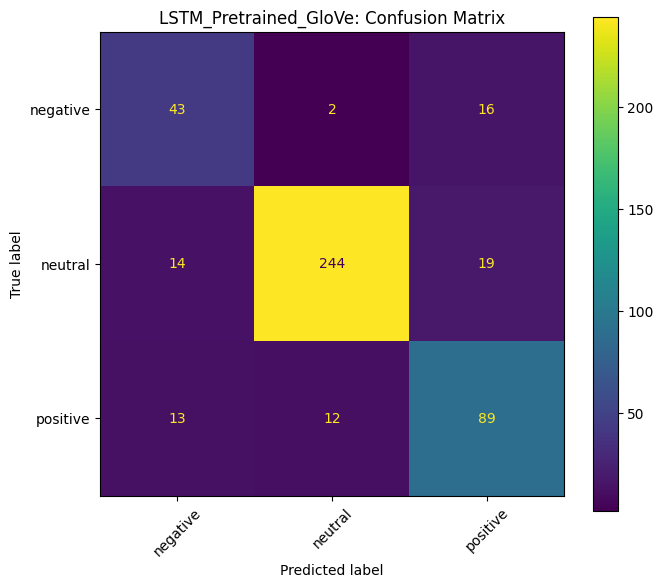

In [ ]:
def build_pretrained_lstm_model(trainable_embedding=False):
    model = Sequential(name='LSTM_Pretrained_GloVe_Embedding')
    model.add(Embedding(
        input_dim=actual_vocab_size,
        output_dim=pretrained_embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=trainable_embedding
    ))
    model.add(SpatialDropout1D(0.2))
    model.add(Bidirectional(LSTM(64, dropout=0.25, recurrent_dropout=0.15)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.45))
    model.add(get_output_layer())
    return model

pretrained_lstm_model = build_pretrained_lstm_model(trainable_embedding=False)
pretrained_lstm_model, pretrained_lstm_history, pretrained_lstm_results = train_model(
    pretrained_lstm_model,
    'LSTM_Pretrained_GloVe'
)

## Step 15: Model Performance Comparison

This section compares all three trained models using a summary table and bar charts. The main comparison metrics are:

- Accuracy
- Weighted precision
- Weighted recall
- Weighted F1-score
- Training time

Weighted F1-score is particularly useful for this task because the class distribution is imbalanced. A model may achieve good accuracy by predicting the majority class often, so the weighted F1-score provides a more balanced view of performance across classes.

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,training_time_seconds
0,LSTM_Trainable,0.851770,0.851363,0.851770,0.851558,67.789718
1,LSTM_Pretrained_GloVe,0.831858,0.843502,0.831858,0.836221,98.616846
2,Simple_RNN,0.659292,0.759710,0.659292,0.635325,18.279565


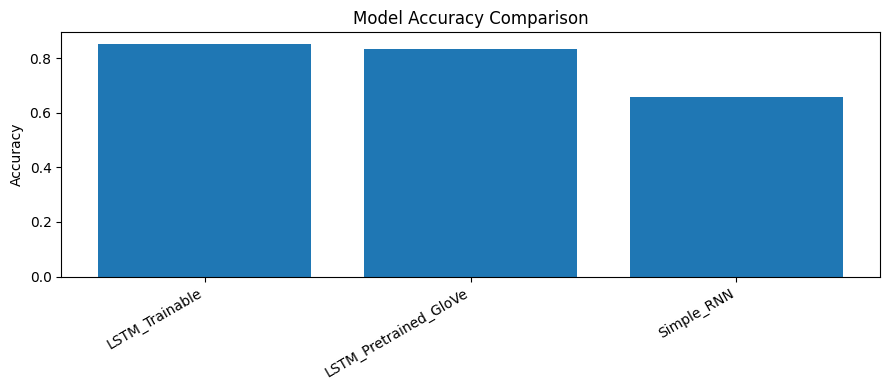

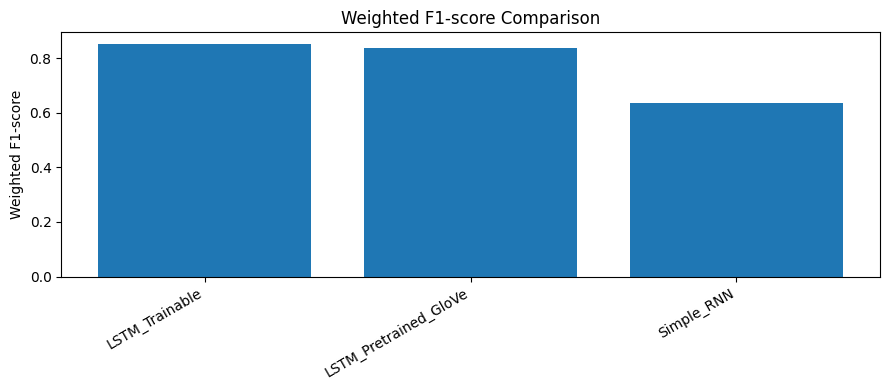

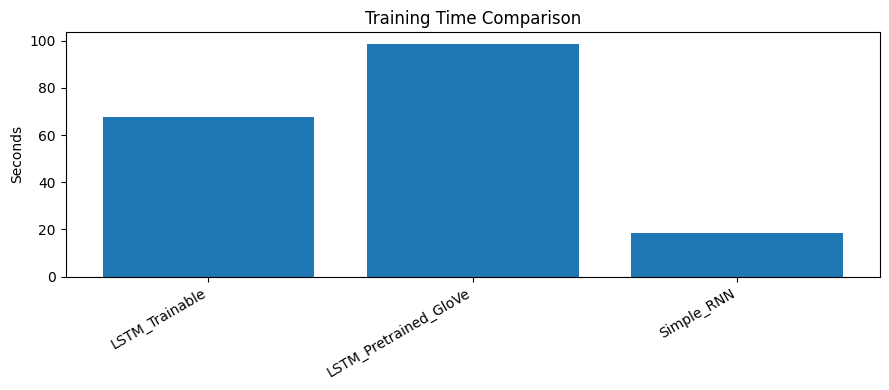

In [ ]:
results_list = [simple_rnn_results, lstm_results, pretrained_lstm_results]
comparison_df = pd.DataFrame(results_list).drop(columns=['predictions'])
comparison_df = comparison_df.sort_values(by='f1_weighted', ascending=False).reset_index(drop=True)
display(comparison_df)

plt.figure(figsize=(9, 4))
plt.bar(comparison_df['model'], comparison_df['accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(comparison_df['model'], comparison_df['f1_weighted'])
plt.title('Weighted F1-score Comparison')
plt.ylabel('Weighted F1-score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(comparison_df['model'], comparison_df['training_time_seconds'])
plt.title('Training Time Comparison')
plt.ylabel('Seconds')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Step 16: Error Analysis of Misclassified Examples

After selecting the best model based on weighted F1-score, this section identifies which test examples were misclassified. Error analysis is important because it shows where the model is still weak even if the overall accuracy is good.

Financial sentiment can be difficult because short phrases may contain mixed signals, incomplete context or domain-specific words such as `loss`, `decline`, `profit`, `cost saving` and `agreement`. Looking at misclassified examples helps explain whether the errors are caused by class imbalance, short context or ambiguous financial wording.

In [ ]:
best_model_name = comparison_df.iloc[0]['model']
print('Best model based on weighted F1-score:', best_model_name)

prediction_lookup = {
    'Simple_RNN': simple_rnn_results['predictions'],
    'LSTM_Trainable': lstm_results['predictions'],
    'LSTM_Pretrained_GloVe': pretrained_lstm_results['predictions']
}

best_predictions = prediction_lookup[best_model_name]

error_df = pd.DataFrame({
    'clean_text': X_test_text.values,
    'true_label': label_encoder.inverse_transform(y_test),
    'predicted_label': label_encoder.inverse_transform(best_predictions)
})
error_df['is_correct'] = error_df['true_label'] == error_df['predicted_label']
misclassified = error_df[~error_df['is_correct']].copy()

print('Total misclassified examples:', len(misclassified))
display(misclassified.head(10))

print('Three examples for report discussion:')
display(misclassified.head(3)[['clean_text', 'true_label', 'predicted_label']])

Best model based on weighted F1-score: LSTM_Trainable
Total misclassified examples: 67


,clean_text,true_label,predicted_label,is_correct
1,company decided to stop operation ruukki const...,neutral,positive,False
2,september alone market declined percent year y...,negative,positive,False
21,return flight from stuttgart every morning wel...,neutral,positive,False
22,according to atrium president ceo matti tikkak...,positive,negative,False
27,measure expected to produce annual cost saving...,positive,neutral,False
31,basware ceo ilkka sihvo comment conjunction in...,positive,neutral,False
37,november finnish paint coating company tikkuri...,neutral,positive,False
42,company also said poland profitability program...,positive,neutral,False
43,adp news nov finnish retail software developer...,positive,negative,False
44,financing arrangement enable company to ensure...,positive,neutral,False


Three examples for report discussion:


,clean_text,true_label,predicted_label
1,company decided to stop operation ruukki const...,neutral,positive
2,september alone market declined percent year y...,negative,positive
21,return flight from stuttgart every morning wel...,neutral,positive


## Step 17: Model Complexity vs Performance

This section summarizes the practical trade-off between model complexity and model performance. A simpler model such as Simple RNN trains quickly but may fail to capture enough sequence information. A trainable LSTM is more computationally expensive but usually provides stronger performance. A pretrained embedding LSTM can benefit from external word knowledge, but it may not always outperform trainable embeddings if the dataset has domain-specific vocabulary.

This comparison supports the report discussion on why the best model was selected and why a more complex model is not always automatically better.

In [ ]:
complexity_notes = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM + Pretrained GloVe Embedding'],
    'Complexity': [
        'Lowest: simple recurrent layer and trainable embedding',
        'Medium: gated recurrent structure, better sequence memory',
        'Medium to high: LSTM plus external semantic word vectors'
    ],
    'Expected Strength': [
        'Fast baseline and easy to explain',
        'Better at capturing longer word dependencies in financial phrases',
        'Better word representation when pretrained vocabulary matches the financial text'
    ],
    'Expected Limitation': [
        'Can struggle with longer sequences and vanishing gradients',
        'Slower than Simple RNN and may overfit on a small dataset',
        'Performance depends on embedding coverage and domain match'
    ]
})
display(complexity_notes)

,Model,Complexity,Expected Strength,Expected Limitation
0,Simple RNN,Lowest: simple recurrent layer and trainable e...,Fast baseline and easy to explain,Can struggle with longer sequences and vanishi...
1,LSTM,"Medium: gated recurrent structure, better sequ...",Better at capturing longer word dependencies i...,Slower than Simple RNN and may overfit on a sm...
2,LSTM + Pretrained GloVe Embedding,Medium to high: LSTM plus external semantic wo...,Better word representation when pretrained voc...,Performance depends on embedding coverage and ...


## Step 18: Real-Time Prediction Function

This section defines a reusable prediction function for new financial phrases. The function applies the same cleaning, tokenization and padding steps used during training before passing the input into the best selected model.

The output includes:

- The cleaned version of the input text
- The predicted sentiment label
- The model confidence
- The probability assigned to each sentiment class

Using the same preprocessing pipeline during prediction is necessary because the model was trained on cleaned and padded sequences, not on raw text.

In [ ]:
# Select best trained model object automatically.
model_object_lookup = {
    'Simple_RNN': simple_rnn_model,
    'LSTM_Trainable': lstm_model,
    'LSTM_Pretrained_GloVe': pretrained_lstm_model
}

best_model = model_object_lookup[best_model_name]


def predict_text(raw_text):
    cleaned = clean_text(raw_text)

    if cleaned.strip() == '':
        return {
            'cleaned_text': cleaned,
            'predicted_label': 'No prediction',
            'confidence': 0.0,
            'class_probabilities': {}
        }

    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = best_model.predict(padded, verbose=0)

    if num_classes == 2:
        positive_prob = float(probs.ravel()[0])
        pred_idx = int(positive_prob >= 0.5)
        probability_values = np.array([1 - positive_prob, positive_prob])
    else:
        probability_values = probs[0]
        pred_idx = int(np.argmax(probability_values))

    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    confidence = float(probability_values[pred_idx])
    class_probabilities = {
        str(class_names[i]): round(float(probability_values[i]), 4)
        for i in range(num_classes)
    }

    return {
        'cleaned_text': cleaned,
        'predicted_label': pred_label,
        'confidence': round(confidence, 4),
        'class_probabilities': class_probabilities
    }

# Test the function with financial phrase examples.
for sentence in FINANCIAL_TEST_SENTENCES:
    print(sentence)
    print(predict_text(sentence))
    print('-' * 80)

The company reported higher revenue and stronger operating profit.
{'cleaned_text': 'company reported higher revenue stronger operating profit', 'predicted_label': 'positive', 'confidence': 0.7697, 'class_probabilities': {'negative': 0.179, 'neutral': 0.0514, 'positive': 0.7697}}
--------------------------------------------------------------------------------
Sales declined sharply and the company reported a loss.
{'cleaned_text': 'sale declined sharply company reported loss', 'predicted_label': 'negative', 'confidence': 0.7411, 'class_probabilities': {'negative': 0.7411, 'neutral': 0.0499, 'positive': 0.2089}}
--------------------------------------------------------------------------------
The company announced a new board meeting for next week.
{'cleaned_text': 'company announced new board meeting next week', 'predicted_label': 'neutral', 'confidence': 0.9927, 'class_probabilities': {'negative': 0.003, 'neutral': 0.9927, 'positive': 0.0043}}
------------------------------------------

## Step 19: Simple GUI with Gradio

This section builds a simple Gradio interface so that a user can type a financial or business news sentence and receive a predicted sentiment label in real time. The interface displays the cleaned text, predicted class, confidence score and class probabilities.

The interface is designed specifically for financial phrase sentiment classification. It should be tested with business or financial statements rather than casual emotional sentences, because the model was trained on financial text.

In [ ]:
import gradio as gr


def gradio_predict(text):
    result = predict_text(text)
    return (
        result['cleaned_text'],
        str(result['predicted_label']),
        result['confidence'],
        result['class_probabilities']
    )

interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=4, placeholder='Enter a financial or business news sentence here...'),
    outputs=[
        gr.Textbox(label='Cleaned Text'),
        gr.Textbox(label='Predicted Class'),
        gr.Number(label='Confidence'),
        gr.Label(label='Class Probabilities')
    ],
    title='Financial Phrase Sentiment Classifier',
    description='Enter a financial or business news phrase. The model predicts negative, neutral, or positive sentiment using the best-performing trained model.',
    examples=FINANCIAL_TEST_SENTENCES
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6c04570049e643a62e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import pickle

os.makedirs('saved_language_model', exist_ok=True)

best_model.save('saved_language_model/best_language_model.keras')
with open('saved_language_model/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('saved_language_model/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

comparison_df.to_csv('saved_language_model/model_comparison.csv', index=False)

print('Saved best model, tokenizer, label encoder and comparison table in saved_language_model/')

Saved best model, tokenizer, label encoder and comparison table in saved_language_model/


## Notebook Summary

This notebook completed the full Task 3 language processing workflow for financial phrase sentiment classification. It loaded and cleaned the dataset, visualized the cleaned text, encoded labels, tokenized and padded sequences, handled class imbalance with class weights, trained three recurrent neural network models, compared their performance, analyzed misclassified examples and created a Gradio interface for real-time prediction.

The comparison section should be used as the main evidence for the final report because it contains the model accuracy, weighted F1-score, training time, confusion matrices and classification reports.